## Step 1: Load and explore data
* Load the training datasets that contain the following information: Categorical, Quantitative, Connectome metrices, and training labels.
* Merge all data on common columns
* Identify and handle missing values, while standardise the formats of data

In [1]:
# Import used libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load all training datasets
train_categorical = pd.read_excel("widsdatathon2025/TRAIN/TRAIN_CATEGORICAL_METADATA.xlsx")
train_connectome = pd.read_csv("widsdatathon2025/TRAIN/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.csv")
train_quantitative = pd.read_excel("widsdatathon2025/TRAIN/TRAIN_QUANTITATIVE_METADATA.xlsx")
train_labels = pd.read_excel("widsdatathon2025/TRAIN/TRAINING_SOLUTIONS.xlsx")

In [3]:
# Examine categorical data
print(train_categorical.head())
print(train_categorical.info())
print(train_categorical.shape)

  participant_id  Basic_Demos_Enroll_Year  Basic_Demos_Study_Site  \
0   UmrK0vMLopoR                     2016                       1   
1   CPaeQkhcjg7d                     2019                       3   
2   Nb4EetVPm3gs                     2016                       1   
3   p4vPhVu91o4b                     2018                       3   
4   M09PXs7arQ5E                     2019                       3   

   PreInt_Demos_Fam_Child_Ethnicity  PreInt_Demos_Fam_Child_Race  \
0                               0.0                            0   
1                               1.0                            2   
2                               1.0                            8   
3                               0.0                            8   
4                               0.0                            1   

   MRI_Track_Scan_Location  Barratt_Barratt_P1_Edu  Barratt_Barratt_P1_Occ  \
0                        1                      21                      45   
1                   

In [4]:
# fMRI data
print(train_connectome.head())
print(train_connectome.info())
print(train_connectome.shape)

  participant_id  0throw_1thcolumn  0throw_2thcolumn  0throw_3thcolumn  \
0   70z8Q2xdTXM3          0.093473          0.146902          0.067893   
1   WHWymJu6zNZi          0.029580          0.179323          0.112933   
2   4PAQp1M6EyAo         -0.051580          0.139734          0.068295   
3   obEacy4Of68I          0.016273          0.204702          0.115980   
4   s7WzzDcmDOhF          0.065771          0.098714          0.097604   

   0throw_4thcolumn  0throw_5thcolumn  0throw_6thcolumn  0throw_7thcolumn  \
0          0.015141          0.070221          0.063997          0.055382   
1          0.038291          0.104899          0.064250          0.008488   
2          0.046991          0.111085          0.026978          0.151377   
3          0.043103          0.056431          0.057615          0.055773   
4          0.112988          0.071139          0.085607          0.019392   

   0throw_8thcolumn  0throw_9thcolumn  ...  195throw_196thcolumn  \
0         -0.035335     

In [5]:
# Quantitative data
print(train_quantitative.head())
print(train_quantitative.info())
print(train_quantitative.shape)

  participant_id  EHQ_EHQ_Total  ColorVision_CV_Score  APQ_P_APQ_P_CP  \
0   UmrK0vMLopoR          40.00                    13               3   
1   CPaeQkhcjg7d         -94.47                    14               3   
2   Nb4EetVPm3gs         -46.67                    14               4   
3   p4vPhVu91o4b         -26.68                    10               5   
4   M09PXs7arQ5E           0.00                    14               5   

   APQ_P_APQ_P_ID  APQ_P_APQ_P_INV  APQ_P_APQ_P_OPD  APQ_P_APQ_P_PM  \
0              10               47               13              11   
1              13               34               18              23   
2              10               35               16              10   
3              12               39               19              16   
4              15               40               20              24   

   APQ_P_APQ_P_PP  SDQ_SDQ_Conduct_Problems  SDQ_SDQ_Difficulties_Total  \
0              28                         0                

In [6]:
# Labels
print(train_labels.head())
print(train_labels.info())
print(train_labels.shape)

  participant_id  ADHD_Outcome  Sex_F
0   UmrK0vMLopoR             1      1
1   CPaeQkhcjg7d             1      0
2   Nb4EetVPm3gs             1      0
3   p4vPhVu91o4b             1      1
4   M09PXs7arQ5E             1      1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   participant_id  1213 non-null   object
 1   ADHD_Outcome    1213 non-null   int64 
 2   Sex_F           1213 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 28.6+ KB
None
(1213, 3)


In [16]:
# Merge datasets on the column 'participant_id'
train_data = pd.merge(train_categorical, train_quantitative, on='participant_id')
train_data = pd.merge(train_data, train_connectome, on='participant_id')
train_data = train_data.merge(train_labels, on='participant_id')

# Delete irrelevant column
train_data.drop(['participant_id'], axis=1, inplace=True)

In [17]:
# Identify missing values
missing_values = train_data.isnull().sum().sort_values(ascending=False)
print("Missing Values:\n", missing_values[missing_values > 0])

Missing Values:
 MRI_Track_Age_at_Scan               360
PreInt_Demos_Fam_Child_Ethnicity     11
dtype: int64


#### **Summary of the Dataset:**
**Categorical Metadata (10 columns, 1213 entries)**

* Contains data regarding study site information, as well as study subject's family background, and demographic data such as ethnicity
* The PreInt_Demos_Fam_Child_Ethnicity column contains 11 missing values to be handled

**Connectime Metrices (19901 columns, 1213 entries)**

* Contains fMRI Data that is recorded

**Quantitative Metadata (19 columns, 1213 entries)**

* Contains data regarding behavioural test scores
* The MRI_Track_Age_at_Scan column contains 360 missing values to be handled

**Training Solutions (3 columns, 1213 entries)**

* Contains data regarding their final diagnosis of ADHD and study subject's gender

After the missing data is handled, it can be seen that all entries for all columns have no missing data from the heatmap above.

## Step 2: Preprocess the data and data visualisation

Any quantitative values that are missing can be replaced using the median value. This strategy doesn't make sense for the categorical data, so we can either replace it with the most common value or create a new Unknown column. In our case, there is only 11 missing categorical datapoints, so adding a new column would increase the dimensionality without too much benefit. Instead, we can replace them with the column's mode.

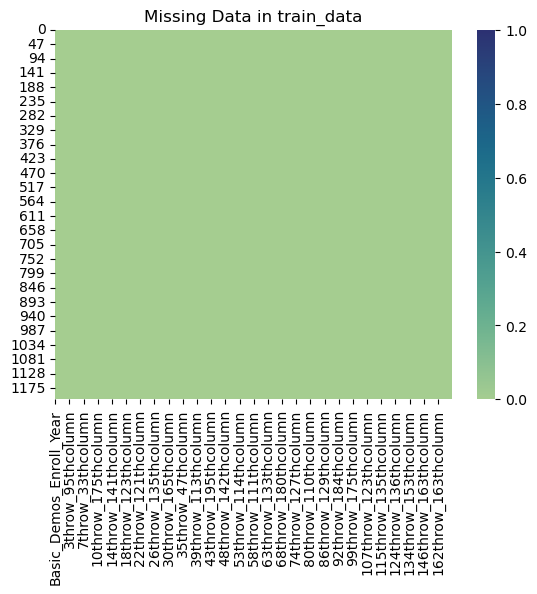

In [24]:
# Handling quantitative missing data by filling missing values with the median
train_data.fillna({"MRI_Track_Age_at_Scan": train_data["MRI_Track_Age_at_Scan"].median()}, inplace=True)

# Handling categorical missing data by filling missing values with the most common value
mode_value = train_data["PreInt_Demos_Fam_Child_Ethnicity"].mode()[0]  # Get the most frequent value
train_data.fillna({"PreInt_Demos_Fam_Child_Ethnicity": mode_value}, inplace=True)

# Visualise missing data on train_data after handling it
sns.heatmap(train_data.isnull(), vmin=0, vmax=1, cmap="crest")
plt.title("Missing Data in train_data")
plt.show()

In [55]:
# Split data into ADHD and no ADHD
adhd = train_data[train_data["ADHD_Outcome"] == 1]
no_adhd = train_data[train_data["ADHD_Outcome"] == 0]

# Split into Female and Male
female = train_data[train_data['Sex_F'] == 1]
male = train_data[train_data['Sex_F'] == 0]

# Print sample size
print(f"Sample Size with ADHD: {adhd.shape[0]}")
print(f"Sample Size without ADHD: {no_adhd.shape[0]}")
print(f"Sample Size of Women: {female.shape[0]}")
print(f"Sample Size of Men: {male.shape[0]}")

Sample Size with ADHD: 831
Sample Size without ADHD: 382
Sample Size of Women: 416
Sample Size of Men: 797


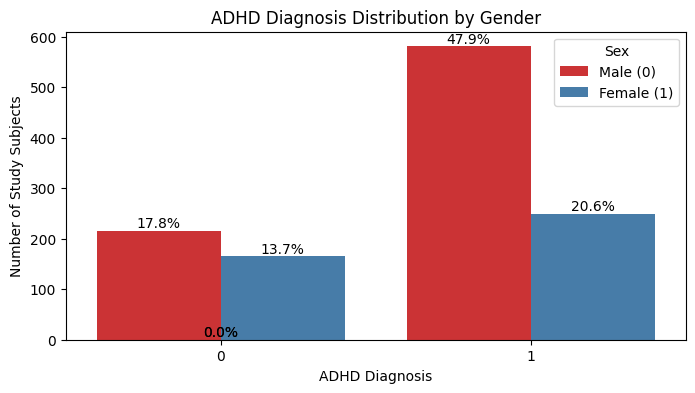

In [56]:
# Visualise the ADHD Diagnosis Distribution by Gender
plt.figure(figsize=(8, 4))
ax = sns.countplot(x='ADHD_Outcome', hue='Sex_F', data=train_data, palette='Set1')

# Adding title and labels
plt.title("ADHD Diagnosis Distribution by Gender")
plt.xlabel("ADHD Diagnosis")
plt.ylabel("Number of Study Subjects")
plt.legend(title="Sex", labels=["Male (0)", "Female (1)"])

# Annotate the bars with percentage, each showing the percentage out of the whole dataset of the specific gender and diagnosis
total = len(train_data)
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black')

plt.show()

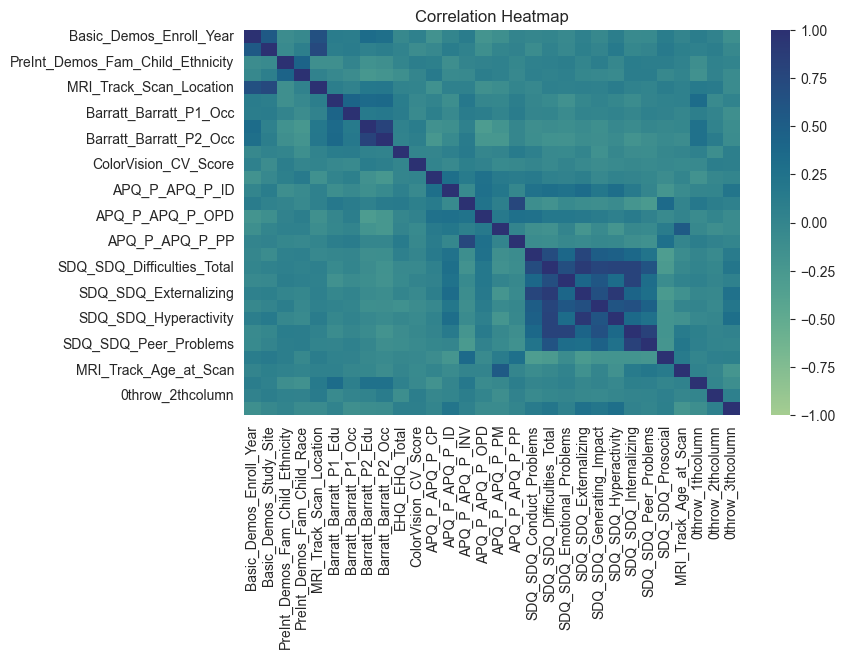

In [62]:
numeric_data = train_data.select_dtypes(include=['number'])
sampled_data = numeric_data.sample(frac=0.10, random_state=42)
corr_matrix = sampled_data.corr(method='spearman')
corr_matrix = sampled_data.iloc[:, :30].corr(method='pearson')
plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, cmap='crest', vmax=1, vmin=-1,cbar=True, annot=False, square=False)
plt.title("Correlation Heatmap")
plt.show()

Following the analysis of the heat correlation map, it can be identified that there are several highly correlated identifiers:
* **Barratt_Barratt_P2_Occ:** Parent 2 Occupation
* **SDQ_SDQ_Conduct_Problems:** Conduct Problems Score
* **SDQ_SDQ_Difficulties_Total:** Total Difficulties Score
* **SDQ_SDQ_Emotional_Problems:** Emotional Problems Scale
* **SDQ_SDQ_Externalizing:** Externalizing Score
* **SDQ_SDQ_Generating_Impact:** Generating Impact Scores
* **SDQ_SDQ_Hyperactivity:** Hyperactivity Scale
* **SDQ_SDQ_Internalizing:** Internalizing Score
* **SDQ_SDQ_Peer_Problems:** Peer Problems Scale

In [72]:
# Percentile Calculation
percentile_calc = ['SDQ_SDQ_Conduct_Problems', 
                   'SDQ_SDQ_Difficulties_Total', 
                   'SDQ_SDQ_Emotional_Problems', 
                   'SDQ_SDQ_Externalizing', 
                   'SDQ_SDQ_Generating_Impact', 
                   'SDQ_SDQ_Hyperactivity', 
                   'SDQ_SDQ_Internalizing', 
                   'SDQ_SDQ_Peer_Problems']
for column in percentile_calc: 
    q1 = np.percentile(train_data[column], 25)  # 25th percentile
    q2 = np.percentile(train_data[column], 50)  # 50th percentile (median)
    q3 = np.percentile(train_data[column], 75)  # 75th percentile
    q4 = np.max(train_data[column])  # 100th percentile (maximum)

    print(f"Percentile calculation for column {column}:")

    print(f"Q1 (25th percentile) : {q1}")
    print(f"Q2 (50th percentile - Median): {q2}")
    print(f"Q3 (75th percentile): {q3}")
    print(f"Q4 (100th percentile - Max): {q4}\n")

Percentile calculation for column SDQ_SDQ_Conduct_Problems:
Q1 (25th percentile) : 0.0
Q2 (50th percentile - Median): 2.0
Q3 (75th percentile): 3.0
Q4 (100th percentile - Max): 10

Percentile calculation for column SDQ_SDQ_Difficulties_Total:
Q1 (25th percentile) : 7.0
Q2 (50th percentile - Median): 12.0
Q3 (75th percentile): 17.0
Q4 (100th percentile - Max): 34

Percentile calculation for column SDQ_SDQ_Emotional_Problems:
Q1 (25th percentile) : 1.0
Q2 (50th percentile - Median): 2.0
Q3 (75th percentile): 4.0
Q4 (100th percentile - Max): 10

Percentile calculation for column SDQ_SDQ_Externalizing:
Q1 (25th percentile) : 4.0
Q2 (50th percentile - Median): 7.0
Q3 (75th percentile): 10.0
Q4 (100th percentile - Max): 20

Percentile calculation for column SDQ_SDQ_Generating_Impact:
Q1 (25th percentile) : 2.0
Q2 (50th percentile - Median): 4.0
Q3 (75th percentile): 6.0
Q4 (100th percentile - Max): 10

Percentile calculation for column SDQ_SDQ_Hyperactivity:
Q1 (25th percentile) : 4.0
Q2 (50

It can therefore be concluded that the following are the Q1-Q4 ranges of the self-assessment **trength and Difficulties Questionnaire**:

| Column                           | 25% Percentile   | Median (50% Percentile) | 75% Percentile   | 100% Percentile |
| -------------------------------- | ---------------- | ----------------------- | ---------------- | --------------- |
| Conduct Problems Score           | 0                | 0-2                     | 2-3              | 3-10            |
| Total Difficulties Score         | 0-7              | 7-12                    | 12-17            | 17-34           |
| Emotional Problems Scale         | 0-1              | 1-2                     | 2-4              | 4-10            |
| Externalizing Score              | 0-4              | 4-7                     | 7-10             | 10-20           |
| Generating Impact Scores         | 0-2              | 2-4                     | 4-6              | 6-10            |
| Hyperactivity Score              | 0-4              | 4-6                     | 6-8              | 8-10            |
| Internalzing Score               | 0-2              | 2-4                     | 4-7              | 7-17            |
| Peer Problems Score              | 0                | 0-2                     | 2-4              | 4-9             |

## Step 3: Model selection

## Step 4: Train the model

## Step 5: Evaluate the model

## Step 6: Hyperparameter tuning